# Train Failure Predictor Models with `Scikit-Learn`

In this notebook we train traditional ML models using Scikit-Learn. The task here is binary classification, to tell if a particular cross section would fail for a given set of internal forces or not.

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import make_scorer, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator
import numpy as np
from utils.ml import calculate_performance_metrics
import matplotlib.pyplot as plt
import json
import warnings
import mlflow
from typing import Optional

warnings.filterwarnings("ignore", message=".*Setting penalty=None will ignore the C and l1_ratio parameters.*")
warnings.filterwarnings("ignore", message=".*The max_iter was reached.*")

In [17]:
config_file_path = "config_rhs.json"
data_file_path = "data_rhs.csv"
mlflow_tracking_uri="sqlite:///mlflow.db"
mlflow_experiment_name=None
task = "geometry_validation"

In [18]:
with open(config_file_path, "r") as f:
    config: dict = json.load(f)

In [19]:
# Load section data
section_data = config["section"]

section_type = config["section"]["type"]
print(f"Section type from config: {section_type}")

section_variables = []
for p in section_data["params"].keys():
    if section_data["params"][p]["variable"]:
        section_variables.append(p)
        
predictor_columns = section_variables
target_column = "valid"

if not mlflow_experiment_name:
    mlflow_experiment_name = f"{task}__{section_type}"

Section type from config: rectangular_hollow_section


In [20]:
df = pd.read_csv(data_file_path)
df["valid"] = ~(df["utilization"].isnull())
df["valid"] = df["valid"].astype(int)
df.head(5)

,d,b,t,r_out,n_r,n,mxx,myy,vx,vy,mzz,area,ixx,iyy,ixy,g_eff,utilization,section_param_id,section_type,valid
0,292.940338,184.123599,16.722934,17.628862,4,-688877.841108,-1.312324e+07,2.412614e+06,-115170.575087,13682.531592,1.153415e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.322426,0,rectangular_hollow_section,1
1,292.940338,184.123599,16.722934,17.628862,4,354570.903962,-2.555486e+07,-5.432602e+06,41320.270385,152295.668465,-2.124411e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.352120,0,rectangular_hollow_section,1
2,292.940338,184.123599,16.722934,17.628862,4,-487911.441850,-6.665061e+06,2.604899e+07,-240323.071707,238398.799619,-1.857385e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.762931,0,rectangular_hollow_section,1
3,292.940338,184.123599,16.722934,17.628862,4,-48213.704668,2.253705e+07,1.034981e+07,-233498.377101,-168306.320838,1.210748e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.647851,0,rectangular_hollow_section,1
4,292.940338,184.123599,16.722934,17.628862,4,-957990.414679,-5.910821e+06,9.593818e+06,17546.913768,-174641.502762,1.074127e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.274913,0,rectangular_hollow_section,1


In [21]:
X = df[predictor_columns]
y = df[target_column]
X.shape, y.shape

((4000, 4), (4000,))

In [22]:
len(df[df[target_column] == 1]), len(df[df[target_column] == 0])

(3720, 280)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=df[target_column]
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2680, 4)
Testing data shape: (1320, 4)


## Train models

In [24]:
mlflow.set_tracking_uri(mlflow_tracking_uri)
experiment = mlflow.set_experiment(mlflow_experiment_name)
mlflow.sklearn.autolog(log_models=False)


def fittness(y_true:np.ndarray, y_pred:np.ndarray) -> float:
    """
    Custom scoring function for evaluating failure prediction models.
    The score is computed as a weighted sum of Negative Predictive Value (NPV)
    and Positive Predictive Value (PPV), with weights of 0.8 and 0.2 respectively.
    
    Parameters
    ----------
    y_true : np.ndarray
        True binary labels (0 or 1).
    y_pred : np.ndarray
        Predicted binary labels (0 or 1).
        
    Returns
    -------
    float
        The computed score, ranging from 0 to 1.
    """
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    [[TN, FP], [FN, TP]] = cm
    score = ((TN + TP) - (FP + FN)) / 2
    return score

scorer = make_scorer(fittness)

In [25]:
def train_model(
    model: BaseEstimator, 
    params_grid: Optional[dict] = None, 
    model_name: Optional[str] = None
) -> BaseEstimator:
    run = mlflow.start_run(run_name=model_name or model.__class__.__name__)  # --- start main run
    run_id = run.info.run_id
    try:
        # ----- tags & baseline params
        mlflow.set_tag("model_class", model.__class__.__name__)
        mlflow.set_tag("stage", "baseline" if not params_grid else "baseline+search")
        mlflow.set_tag("task", task)
        mlflow.set_tag("section_type", section_type)
        mlflow.set_tag("library", "sklearn")

        # ----- fit on train
        model.fit(X_train, y_train.values.ravel())
        
        # define cross-validation strategy and log parameters
        kf_params = {"n_splits": 6, "random_state": 42, "shuffle": True}
        kf = StratifiedKFold(**kf_params)
        logged_kf_params = {f"kf__{k}": v for k, v in kf_params.items()}
        mlflow.log_params(logged_kf_params)

        # ----- hyperparameter search (optional)
        if params_grid:
            mlflow.log_dict(params_grid, "param_grid.json")
            mlflow.start_run(run_name=f"{model_name} - RandomizedSearchCV", nested=True)  #-- start nested run
            try:
                cv = RandomizedSearchCV(
                    estimator=model,
                    param_distributions=params_grid,
                    cv=kf,
                    n_iter=10,
                    scoring=scorer,
                    n_jobs=-1,
                    random_state=42,
                    refit=True,
                )
                cv.fit(X_train, y_train.values.ravel())
                model = cv.best_estimator_
            finally:
                mlflow.end_run()  # --- end nested run
        
        # log the final model
        mlflow.sklearn.log_model(model, name="model", input_example=X_train.iloc[:5])
        
        # log cv scores
        cv_scores = cross_val_score(model, X_train, y_train.values.ravel(), cv=kf, scoring=scorer)
        mlflow.log_metric("train_cv_score_mean", float(np.mean(cv_scores)))
        mlflow.log_metric("train_cv_score_std", float(np.std(cv_scores)))

        # log normalized confusion matrix metrics
        y_pred = model.predict(X_test)
        [[TN, FP], [FN, TP]] = confusion_matrix(y_test, y_pred, normalize='true')
        metrics_normalized = {
            "test_TN_normalized": TN,
            "test_FP_normalized": FP,
            "test_FN_normalized": FN,
            "test_TP_normalized": TP,
        }
        mlflow.log_metrics(metrics_normalized)
        
        # log other metrics
        cm = confusion_matrix(y_test, y_pred)
        metrics = calculate_performance_metrics(cm)
        test_metrics = {f"test_{k}": v for k, v in metrics.items()}
        mlflow.log_metrics(test_metrics)
        
        # log composit score
        test_score = fittness(y_test, y_pred)
        mlflow.log_metric("test_score", test_score)
        
        return run_id, model

    finally:
        mlflow.end_run()  # --- end main run
        print("MLflow run ended.")

In [26]:
def plot_and_log_confusion_matrix(model: BaseEstimator, run_id: str) -> None:
    # make predictions on the test data
    y_pred = model.predict(X_test)

    # display the confusion matrix as a plot
    fig, ax = plt.subplots()
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
    disp.plot(cmap='Blues', ax=ax)
    
    # log figure
    with mlflow.start_run(run_id=run_id):
        mlflow.log_figure(fig, "test_confusion_matrix.png")

### Logistic Regression

#### Train baseline model

/Users/baloghbence/Library/Caches/pypoetry/virtualenvs/sigmaepsilon-solid-fourier-2jj81J8s-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2025/11/12 18:41:22 INFO mlflow.sklearn.utils: Logging the 5 best runs, 5 runs will be omitted.
/Users/baloghbence/Library/Caches/pypoetry/virtualenvs/sigmaepsilon-solid-fourier-2jj81J8s-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic d

MLflow run ended.


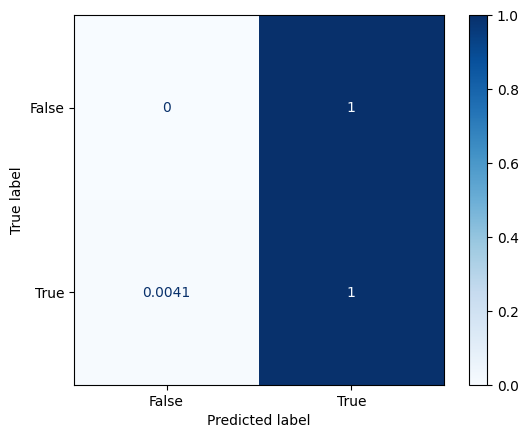

In [27]:
model_name = "LogReg"
steps = [
    ("scaling", StandardScaler()),
    ("classification", LogisticRegression(solver='saga', max_iter=100))
]
pipeline = Pipeline(steps)
params_grid = {
    "classification__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classification__penalty": ["l1", "l2", None],
}

run_id, model = train_model(pipeline, params_grid=params_grid, model_name=model_name)

%matplotlib inline
plot_and_log_confusion_matrix(model, run_id)

#### Train model with degree-3 polynomial features

2025/11/12 18:41:26 INFO mlflow.sklearn.utils: Logging the 5 best runs, 5 runs will be omitted.
/Users/baloghbence/Library/Caches/pypoetry/virtualenvs/sigmaepsilon-solid-fourier-2jj81J8s-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


MLflow run ended.


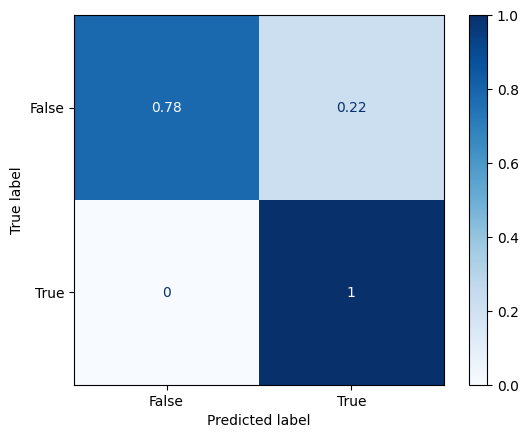

In [28]:
model_name = "LogReg Poly3"
steps = [
    ("feature_eng", PolynomialFeatures(3, include_bias=False)),
    ("scaling", StandardScaler()),
    ("classification", LogisticRegression(solver='saga', max_iter=100))
]
pipeline = Pipeline(steps)
params_grid = {
    "classification__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classification__penalty": ["l1", "l2", None],
}

run_id, model = train_model(pipeline, params_grid=params_grid, model_name=model_name)

%matplotlib inline
plot_and_log_confusion_matrix(model, run_id)

### Support Vector Machine

#### Train baseline model

/Users/baloghbence/Library/Caches/pypoetry/virtualenvs/sigmaepsilon-solid-fourier-2jj81J8s-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


MLflow run ended.


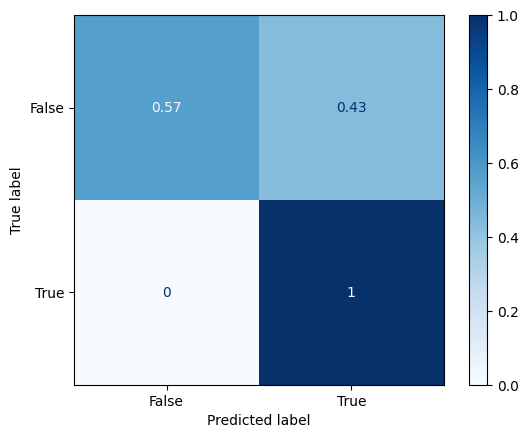

In [29]:
model_name = "SVN"
steps = [
    ("scaling", StandardScaler()),
    ("classification", svm.SVC())
]
pipeline = Pipeline(steps)

run_id, model = train_model(pipeline, model_name=model_name)

%matplotlib inline
plot_and_log_confusion_matrix(model, run_id)

#### Train model with a polynomial kernel

2025/11/12 18:41:33 INFO mlflow.sklearn.utils: Logging the 5 best runs, 5 runs will be omitted.
/Users/baloghbence/Library/Caches/pypoetry/virtualenvs/sigmaepsilon-solid-fourier-2jj81J8s-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


MLflow run ended.


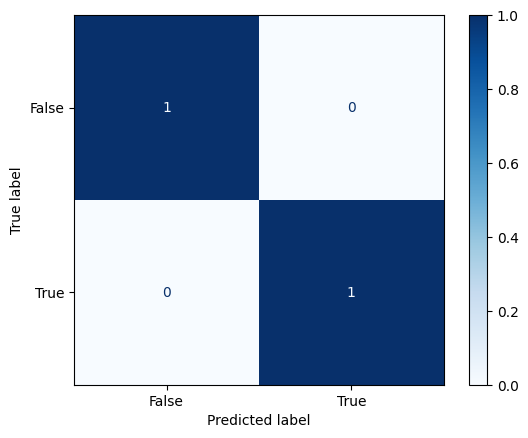

In [30]:
model_name = "SVN PolyKernel"
steps = [
    ("scaling", StandardScaler()),
    ("classification", svm.SVC(kernel="poly"))
]
pipeline = Pipeline(steps)
params_grid = {
    "classification__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "classification__degree": [2, 3, 4, 5],
    "classification__gamma": ["scale", "auto"],
}

run_id, model = train_model(pipeline, params_grid=params_grid, model_name=model_name)

%matplotlib inline
plot_and_log_confusion_matrix(model, run_id)